# **Aprendizaje Automático II: Apredizaje no supervisado**

## **Carga de librerias**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples

Cargamos nuestro dataset (usaremos el que hemos preprocesado):

In [2]:
# Carga del dataset
dataset_spotify = pd.read_csv('../data/dataset_preprocesado.csv', index_col=0)
dataset_spotify.head(5)

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo
0,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460
1,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203
2,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909
3,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155
4,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989


## **Tarea 3: Aplicación de algoritmos de clústering de densidad**
Aplicaremos en este caso, **DBSCAN.**

### **Tarea 3.1**
Nos piden: **`Realiza el pre-procesamiento necesario para poder aplicar algoritmos de densidad.`**

Para el clustering por densidad, reutilizamos el dataset preprocesado en la **Tarea 0 (Notebook '1_jerarquico.ipynb').** Se han mantenido las transformaciones para corregir el sesgo (*skewness*) y el escalado **MinMaxScaler**, ya que DBSCAN es extremadamente sensible a las magnitudes. Este escalado asegura que todas las dimensiones tengan el mismo peso, permitiendo que el cálculo de la distancia euclídea (parámetro `eps`) sea consistente y equilibrado entre variables de distinta naturaleza, como el `tempo` (ritmo) y la `acousticness` (textura sonora).

Solo haremos un cambio, y es `quitar la columna mode,` ya que, al ser binaria, puede el algoritmo **darle más peso, cosa que, al contrario que los algoritmos jerárquicos o particionales, no afectaban mucho.** Por ello, procedemos a quitarla:

In [3]:
# Borramos la columna mode
dataset_spotify_preprocesado = dataset_spotify.drop(columns=['mode'])
dataset_spotify_preprocesado

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
0,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.2120,0.686460
1,0.9160,0.475,0.442616,0.130,0.956000,0.1010,0.0510,0.475203
2,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.1170,0.558909
3,0.4750,0.624,0.357418,0.596,0.203000,0.1190,0.0314,0.512155
4,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0444,0.528989
...,...,...,...,...,...,...,...,...
4760,0.2020,0.745,0.505967,0.477,0.000000,0.1200,0.0880,0.576026
4761,0.9610,0.537,0.506339,0.143,0.005720,0.1100,0.0331,0.555124
4762,0.4380,0.282,0.394865,0.158,0.134000,0.4740,0.0311,0.275839
4763,0.9320,0.632,0.522425,0.284,0.000476,0.2330,0.0801,0.548875


### **Tarea 3.2**
Nos piden: **`Establece el radio (eps) y número de puntos mínimo número más adecuado de clusters para el dataset proporcionado.`**

Primero, debemos de entender `qué hace DBSCAN:`
- Según una variable **eps y min_samples le definamos,** hará mejor o peor los clústers.
- `eps` es la distancia máxima en la que cada punto podrá `mirar a su alrededor y ver qué puntos caen en su radio.`
- `min_samples` es el **mínimo número de puntos para considerar a un punto un core point (base del clúster).**
- Si in punto es core point, `se le etiqueta como un clúster y se evalua a sus vecinos capturados.`
- Si los vecinos son core points, **se añade sus vecinos para evaluarlos.**
- Tanto sea o no sea core point, si un punto es evaluado `debido a que se le añadió por un core point,` pasará a ser de ese clúster a menos que ya sea de otro.
- Si al finalizar quedan puntos sin marcar, se les considera `puntos ruidosos.`

Con esto, sabemos que hay que tener cuidado `a la hora de elegir eps y min_samples.` Primero, veremos los **posibles mejores eps para DBSCAN según técnicas.** Luego, veremos lo mismo **para min_samples.**

#### **¿Cómo obtenemos un min_samples adecuado?**
Para ello, veremos diferentes técnicas como `el clásico de número de dimensiones * 2 o la de el logaritmo neperiano del número de registros.` Veremos estas 2 técnicas y veremos cuales pueden ser los mejores min_samples (que de esto, depende también el esp).

##### **Número de dimensiones * 2**
Esta es una técnica muy utilizada: Consiste en `multiplicar por 2 el número de dimensiones que tiene nuestro dataset final.` Esto funciona porque:
* Matemáticamente, para formar `estructuras en una dimensión 'D', necesitas como mínimo D + 1 puntos.`
* Al saber esto, multiplicamos por 2, a parte de cumplir con lo primero que dijimos, porque los datos (como hemos visto), **nunca están perfectamente limpios.** Es decir, que habrá outliers que, aunque sean reales, `complican a la hora de formar los grupos.`

Por estas razones, creemos que puede funcionar esta técnica. Vamos a aplicarla:

In [4]:
# Calculamos el total de dimensiones
dimensiones_dataset = dataset_spotify_preprocesado.shape[1]

# Min samples es el doble de las dimensiones
min_samples_dimension = dimensiones_dataset * 2

# Mostramos el posible min_samples
print(f'Un posible candidato para min_samples segun las dimensiones es {min_samples_dimension}')

Un posible candidato para min_samples segun las dimensiones es 16


##### **Logaritmo neperiano del número de muestras**
Esta es otra técnica que se suele utilizar: Consiste en `aplicar el logaritmo neperiano al total de muestras que tenemos (ln(num_samples)).` Esto funciona porque:
* Cuantos más datos tenemos (registros), **más fácil es agrupar un pequeño grupo de puntos.** Esto se debe al gran crecimiento de los registros.
* Cuanto `más grande es el número, más despacio crece el logaritmo.` Por lo que, para datasets medianos-grandes, suele ser esto muy fiable.

Por estas razones, creemos que puede funcionar esta técnica. Vamos a aplicarla:

In [5]:
# Calculamos el total de registros
numero_registros = dataset_spotify_preprocesado.shape[0]

# Min samples es el ln de los registros
min_samples_registros = int(np.log(numero_registros))

# Mostramos el posible min_samples
print(f'Un posible candidato para min_samples según el numero de registros es {min_samples_registros}')

Un posible candidato para min_samples según el numero de registros es 8


##### **¿Con cuál nos quedamos?**
Ambos nos dan 2 resultados distintos: El de dimensiones 16 y el de log 8. Para ello, vamos a pasar a analizar el esp, ya que, justamente, hay un método `que depende de la buena elección del min_samples.`

#### **¿Cómo obtenemos un eps adecuado?**
Para ello, veremos diferentes técnicas como `el k-distances plot.` Veremos esta técnica ya que es la más eficiente y fundamentada (y no necesita de ejecutar DBSCAN) y veremos cuales pueden ser los mejores eps.

##### **K-distance plot**
Esta técnica es la más usada para estimar el parámetro `eps`. Consiste en calcular la distancia de cada punto a su **k-ésimo vecino más cercano** (donde $k$ suele coincidir con el valor elegido para `min_samples`). 

Al representar estas distancias de forma ordenada:
1. Los puntos que pertenecen a clústeres densos tendrán distancias pequeñas y similares entre sí, creando una zona plana o de crecimiento lento en el gráfico.
2. Los puntos ruidosos o aislados mostrarán distancias mucho mayores, provocando que la curva se dispare hacia arriba.
3. **El "Codo" (Knee/Elbow):** El punto de máxima curvatura nos indica el umbral donde la densidad cambia drásticamente. El valor de la distancia en ese "codo" es nuestra mejor estimación para el radio `eps`.

Vamos a implementarlo para verlo gráficamente y, de paso, a confirmar `cual min_samples funcionaría mejor:`

In [6]:
# Funcion que grafica el k-distance plot segun un eps recibido
def dibujar_k_distance_plot(df, min_samples):

    # Vemos cuantos min_samples vamos a probar
    num_min_samples = len(min_samples)

    # Creamos el lienzo
    fig, axes = plt.subplots(num_min_samples, 1, figsize=(20, num_min_samples * 5))

    # Probamos cada min_samples para obtener el k-vecino mas lejano (min_sample - 1)
    for axe, min_sample in zip(axes, min_samples):

        # Calculamos las distancias entre puntos (hasta el k vecino mas lejano)
        nbrs = NearestNeighbors(n_neighbors=min_sample).fit(df)
        distances, indices = nbrs.kneighbors(df)

        # Ordenamos las distancias, obteniendo la del vecino k-1 mas lejano
        k_distances = np.sort(distances[:, min_sample - 1])

        # Obtenemos el eps mejor
        posible_valor_eps = np.percentile(k_distances, 85)  # El percentil 85 creemos que funcionara mejor debido a la gran cantidad de outliers

        # Graficamos las distancias
        axe.plot(k_distances)

        # Ponemos el punto donde esta la mayor curvatura
        axe.axhline(y=posible_valor_eps, color='red', linestyle='--', label=f'Eps sugerido: {posible_valor_eps:.4f}')

        # Ponemos nombres
        axe.set_ylabel('k-distances')
        axe.set_xlabel('Puntos ordenados por distancias')
        axe.set_title(f'k-distance plot con minsample {min_sample}')
        axe.legend()

    # Mostramos
    plt.tight_layout()
    plt.show()

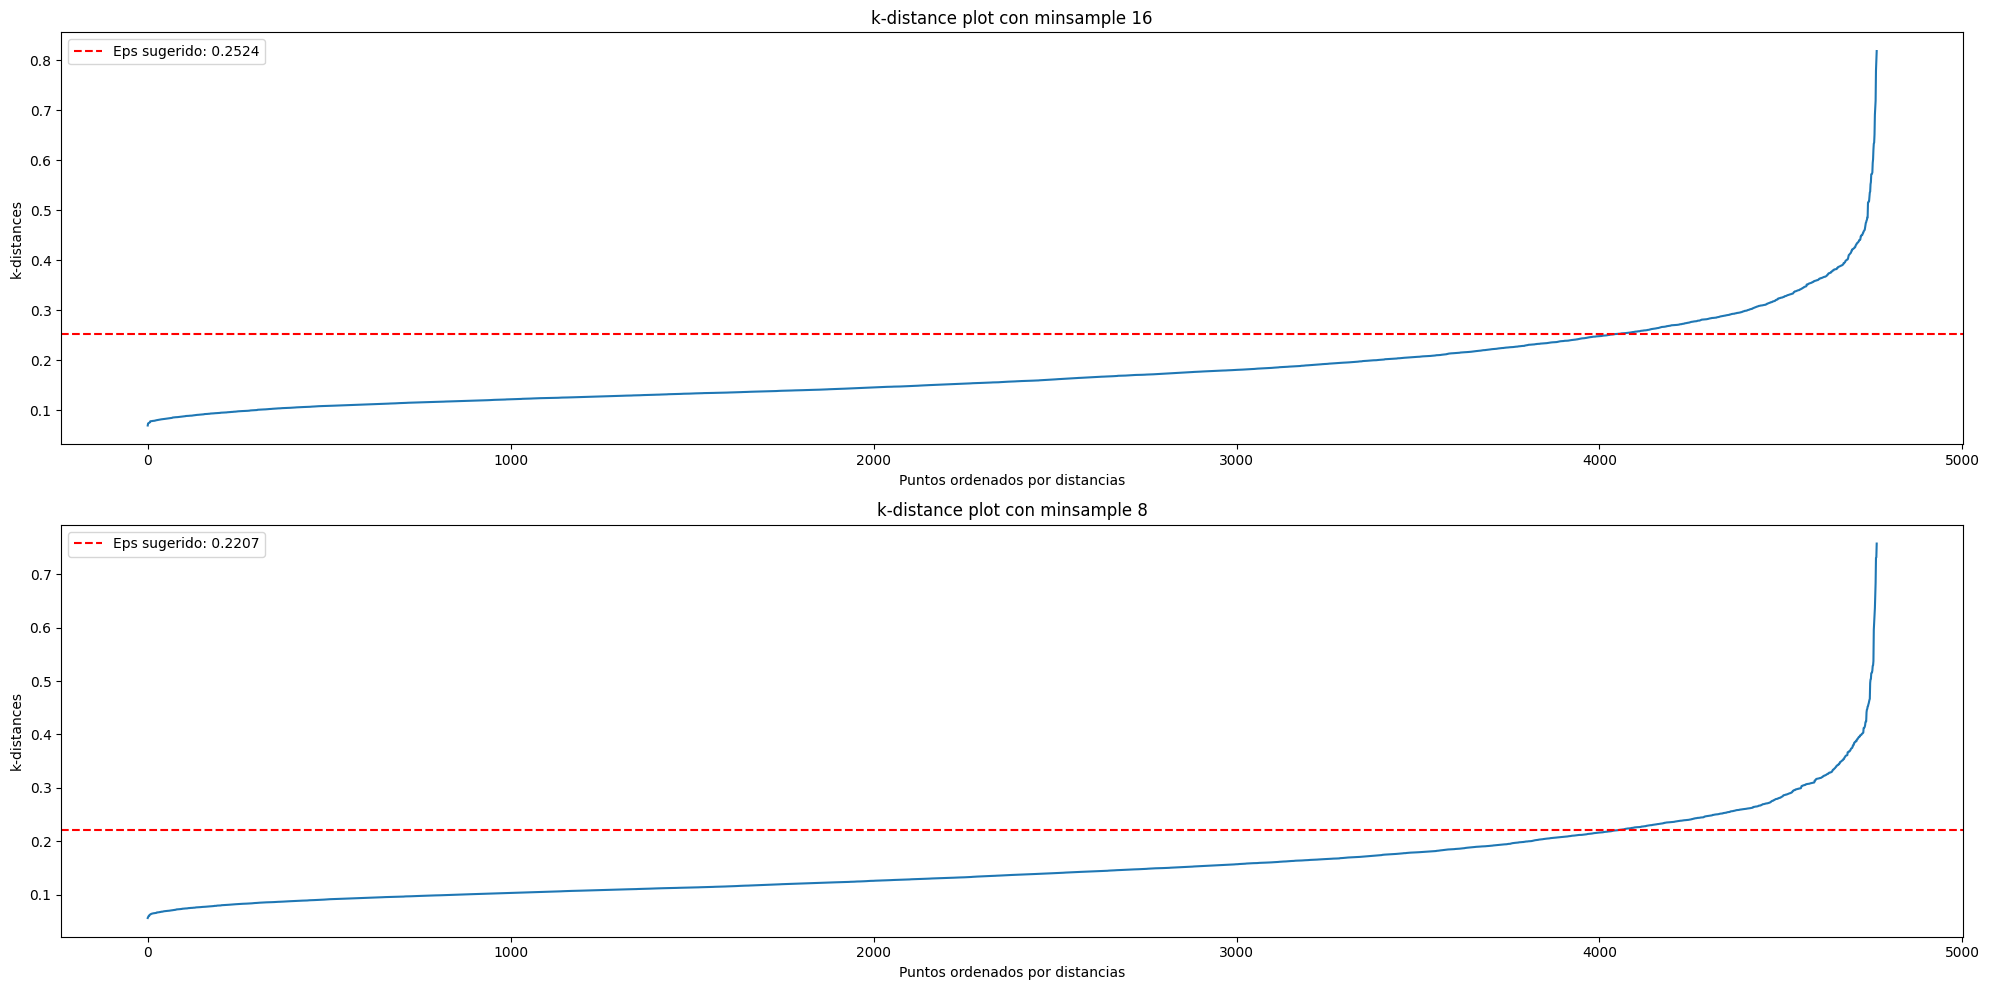

In [7]:
# Definimos los min samples a probar
min_samples_probar = [min_samples_dimension, min_samples_registros]

# Mostramos los k-distance plot
dibujar_k_distance_plot(dataset_spotify_preprocesado, min_samples_probar)

Como vemos, en teoría, los eps `son muy similares,` ya que tenemos por un lado, 0.2524 para **un min_sample=16** y 0.2207 para **min_sample=8.** Como son valores muy cercanos, vamos a `probar ambos valores, combinando ambos para ver quién da mejores resultados.` Por lo cual, vamos a probar esto:

In [8]:
# Parametros a probar
eps_min_samples = [
    (0.2524, 8),
    (0.2207, 8),
    (0.2524, 18),
    (0.2207, 18)
]

eps_min_samples

[(0.2524, 8), (0.2207, 8), (0.2524, 18), (0.2207, 18)]

### **Tarea 3.3**
Nos piden: **`¿Cómo varía la calidad del clustering con diferentes valores de 'eps' y de 'minpoints'?`**

Llegó la hora, y vamos a probar DBSCAN `con los eps y minpoints (min_samples en DBSCAN),` viendo como varía la **calidad de los clústers.**

Vamos a ejecutar de una DBSCAN con todos estos hiperparámetros, y luego, analizamos cada resultado:

In [9]:
# Lista donde guardamos resultados
resultados_dbscan = list()

# Recorremos un bucle para probar cada hiperparametro
for eps, min_sample in eps_min_samples:

    # Configuramos DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_sample, metric='manhattan', n_jobs=-1)  # Probamos manhattan ya que es mas resistente a los outliers
    ## Aparte, no tenemos la opcion de ward para euclidean, por lo cual, manhattan resulto funcionar mejor

    # Ejecutamos el algoritmo, obteniendo los labels
    labels = dbscan.fit_predict(dataset_spotify_preprocesado)

    # Lo uardamos
    resultados_dbscan.append(labels)

# Vemos el dict
resultados_dbscan

[array([-1,  0,  1, ..., -1,  1,  1], shape=(4765,)),
 array([-1,  2, -1, ..., -1, -1,  0], shape=(4765,)),
 array([-1, -1,  0, ..., -1, -1,  0], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1,  1], shape=(4765,))]

Ejecutado el algoritmo, vamos a analizar los resultados.

In [10]:
# Funcion que añade al df los clusters de cada registro
def aniadir_cluster_df(df, resultado_cluster):

    # Añadimos los labels al cluster
    df_cluster = pd.concat([df, pd.DataFrame({f'cluster': resultado_cluster})], axis=1)

    # Devolvemos el df
    return df_cluster

#### **Analizando con eps 0.2524 y min_sample 8**
Vamos a ver a primeras como son los clústers que genera.

Primero, veremos el tamaño de cada clúster:

In [11]:
# Resultado a probar
resultado_8_25 = resultados_dbscan[0]

# Tamanio de los clusters
pd.Series(resultado_8_25).value_counts()

 1    2463
-1    2117
 0     179
 2       6
Name: count, dtype: int64

Vemos de primeras, `clústers genéricos, siendo uno de ellos muy pequeño y la mayoría ruido.` Vamos a analizar cada clúster como es:

In [12]:
# Obtenemos el df para comparar
df_comparar_8_25 = aniadir_cluster_df(dataset_spotify_preprocesado, resultado_8_25)

# Sacamos la media de los datos de los clusters
df_comparar_8_25.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.402954,0.568647,0.477340,0.548940,0.262628,0.219129,0.107083,0.518833
0,0.951240,0.537823,0.421446,0.088707,0.920246,0.103748,0.048693,0.415334
1,0.284376,0.636937,0.489543,0.611378,0.003788,0.141524,0.056135,0.499900
2,0.931333,0.315333,0.484481,0.230833,0.005516,0.145983,0.037967,0.713586


Con esto, buscando en internet, vemos lo siguiente:

**Interpretación de los clusters obtenidos**

Los clusters generados por DBSCAN muestran perfiles sonoros claramente diferenciados, por lo que **sí logran separarse entre sí** y no son redundantes:

- **Cluster 0**  
  Muy acústico e instrumental, con energía muy baja y casi sin voz.  
  Representa música **ambiental, instrumental o acústica muy suave**.

- **Cluster 1**  
  Alta energía y danceability, con instrumentalness casi nulo.  
  Perfil típico de **pop comercial o dance suave**.

- **Cluster 2**  
  Muy acústico pero con algo de ritmo, energía baja-media.  
  Corresponde a estilos como **folk, indie acústico o cantautor**.

- **Cluster -1 (outliers)**  
  Mezcla heterogénea con valores intermedios.  
  Incluye canciones **híbridas o alternativas** que no encajan en ninguna densidad dominante.

En conjunto, los clusters representan **tipos de sonido distintos**, coherentes con categorías musicales reales.

Pues aunque sean pocos, DBSCAN `logra generar clústers que tienen sentido y logran ser diferenciales.` Al tener un dataset bastante sucio, pudo sacar bien los clústers. Probaremos ahora con los demás a ver si generamos más.

#### **Analizando con eps 0.2207 y min_sample 8**
El ideal según min_samples a 8. Vamos a ver si eso se traduce a la realidad.

Primero, veremos el tamaño de cada clúster:

In [13]:
# Resultado a probar
resultado_8_22 = resultados_dbscan[1]

# Tamanio de los clusters
pd.Series(resultado_8_22).value_counts()

-1    2795
 0    1831
 2      71
 1      27
 3      17
 4      10
 6       7
 5       7
Name: count, dtype: int64

Vemos algo parecido que antes: `Clústers que podrían ser genéricos y dominantes.` Lo bueno es que vemos más clústers, pero muy pequeños. Vamos a analizar cada clúster formado:

In [14]:
# Obtenemos el df para comparar
df_comparar_8_22 = aniadir_cluster_df(dataset_spotify_preprocesado, resultado_8_22)

# Sacamos la media de los datos de los clusters
df_comparar_8_22.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.394666,0.578372,0.479648,0.550839,0.218247,0.205573,0.097166,0.514698
0,0.274889,0.642074,0.489233,0.615082,0.002457,0.131550,0.052187,0.496969
1,0.991111,0.696111,0.305475,0.018401,0.959815,0.108489,0.074081,0.366718
2,0.937296,0.605986,0.439171,0.123832,0.914296,0.105823,0.041311,0.469368
3,0.983706,0.332176,0.440572,0.030595,0.930353,0.086912,0.044788,0.296942
4,0.966600,0.113450,0.461910,0.020091,0.892200,0.098080,0.041820,0.316684
5,0.312286,0.677000,0.462423,0.664714,0.000226,0.113743,0.055557,0.682132
6,0.147800,0.747857,0.491711,0.674286,0.000127,0.396714,0.037743,0.500394


Podemos deducir lo siguiente:

**Interpretación de los clusters obtenidos**

Los centroides muestran que los clusters representan **perfiles sonoros muy diferenciados**, no redundantes. Cada uno captura un tipo de sonido característico:

- **Cluster -1 (outliers estructurados)**  
  Valores intermedios en casi todo. Mezcla de energía, acústica y algo de instrumentalness.  
  Representa canciones **híbridas o difíciles de clasificar**, típicas de estilos alternativos o experimentales.

- **Cluster 0**  
  Danceability y energía moderadas, instrumentalness casi nula.  
  Perfil típico de **pop / dance suave**.

- **Cluster 1**  
  Acousticness e instrumentalness extremadamente altos, energía muy baja.  
  Música **ambiental, instrumental o acústica muy suave**.

- **Cluster 2**  
  Muy acústico, con algo de ritmo y energía baja-media.  
  Representa **folk, indie acústico o cantautor**.

- **Cluster 3**  
  Muy acústico, pero con danceability baja y tempo bajo.  
  Perfil de **baladas acústicas lentas o piezas íntimas**.

- **Cluster 4**  
  Muy acústico, muy poco bailable y energía mínima.  
  Canciones **acústicas muy tranquilas**, casi meditativas.

- **Cluster 5**  
  Danceability alta, energía alta, instrumentalness casi cero.  
  Perfil de **pop energético o dance más intenso**.

- **Cluster 6**  
  Danceability muy alta, energía alta, liveness elevada.  
  Representa música **muy rítmica y animada**, posiblemente temas más “vivos” o con presencia de público.

En conjunto, los clusters capturan **distintos estilos sonoros** dentro del dataset, desde música ambiental e instrumental hasta pop energético y folk acústico, mostrando que DBSCAN ha logrado separar grupos con identidades claras.

Pues aunque tenemos más clústers, vemos que tenemos `subgeneros como el pop.` Por lo demás, nos hemos acercado algo a los 8 clústers del **clústering agglomerativo.** Veremos si al final, con métricas, si son buenos los clústers o no.

#### **Analizando con eps 0.2524 y min_sample 16**
Vamos a ver ahora con más min_samples, a ver si cambia la cosa primeras como son los clústers que genera. Este es el ideal según min_samples 16.

Primero, veremos el tamaño de cada clúster:

In [15]:
# Resultado a probar
resultado_16_25 = resultados_dbscan[2]

# Tamanio de los clusters
pd.Series(resultado_16_25).value_counts()

-1    2735
 0    1976
 1      54
Name: count, dtype: int64

Vemos algo no visto hasta ahora: Solo `2 clústers, y la mayoría de puntos siendo ruido.` No tiene buena pinta, pero aún asi, veremos los datos de los clústers:

In [16]:
# Obtenemos el df para comparar
df_comparar_16_25 = aniadir_cluster_df(dataset_spotify_preprocesado, resultado_16_25)

# Sacamos la media de los datos de los clusters
df_comparar_16_25.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.421001,0.572998,0.476745,0.532291,0.246579,0.205080,0.097204,0.510277
0,0.267020,0.643099,0.489270,0.618609,0.003431,0.134312,0.053518,0.498280
1,0.930778,0.608333,0.442991,0.129731,0.905500,0.104119,0.042500,0.519348


Podemos deducir lo siguiente:

**Interpretación de los clusters obtenidos**

Los centroides muestran tres perfiles sonoros muy distintos, además del grupo de outliers:

- **Cluster -1 (outliers estructurados)**  
  Valores intermedios en energía, danceability y acousticness, con instrumentalness moderado.  
  Representa canciones **híbridas o difíciles de clasificar**, típicas de estilos alternativos o mezclas entre acústico y electrónico.

- **Cluster 0**  
  Danceability y energía relativamente altas, instrumentalness casi nulo.  
  Perfil típico de **pop o dance suave**, con presencia vocal clara y ritmo marcado.

- **Cluster 1**  
  Acousticness e instrumentalness muy altos, energía muy baja.  
  Representa música **ambiental, instrumental o acústica muy suave**, con poca voz y carácter relajado.

En conjunto, los clusters capturan **tres estilos sonoros bien diferenciados**:  
pop/dance, acústico‑instrumental, y un grupo híbrido que DBSCAN identifica como ruido estructurado.

Es verdad que logran diferenciarse en general, pero 2 clústers y `muchos puntos sucios` es una mala señal **de fallo de hiperparámetros.** Seguramente, la última combinación falle, pero vamos a probarla.

#### **Analizando con eps 0.2207 y min_sample 16**
Vamos a ver ahora con más min_samples, pero menor eps.

Primero, veremos el tamaño de cada clúster:

In [17]:
# Resultado a probar
resultado_16_22 = resultados_dbscan[3]

# Tamanio de los clusters
pd.Series(resultado_16_22).value_counts()

-1    3713
 0     947
 1      77
 2      28
Name: count, dtype: int64

Vemos una pequeña mejora: solo `3 clústers, similar a min_samples 8 y eps 0.2524.` Sigue siendo pocos clústers, pero vamos a ver los datos de cada uno:

In [18]:
# Obtenemos el df para comparar
df_comparar_16_22 = aniadir_cluster_df(dataset_spotify_preprocesado, resultado_16_22)

# Sacamos la media de los datos de los clusters
df_comparar_16_22.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.417079,0.587988,0.479072,0.536286,0.195977,0.190621,0.086435,0.510037
0,0.095182,0.663782,0.489971,0.702318,0.002367,0.118721,0.051825,0.493144
1,0.851805,0.573649,0.492724,0.276714,0.001821,0.109969,0.036566,0.484415
2,0.892500,0.528250,0.495752,0.270036,0.000934,0.115968,0.038229,0.363490


Podemos deducir lo siguiente:

**Interpretación de los clusters obtenidos**

Los centroides muestran que los clusters son **claramente diferenciables** y no representan grupos redundantes. Cada uno captura un perfil sonoro distinto:

- **Cluster -1 (outliers estructurados)**  
  Valores intermedios en energía, danceability y acousticness, con instrumentalness moderado.  
  Representa canciones **híbridas o difíciles de clasificar**, típicas de estilos alternativos o mezclas acústico‑electrónicas.

- **Cluster 0**  
  Acousticness muy baja, danceability alta y energy alta, instrumentalness casi nulo.  
  Perfil típico de **pop energético o dance**, con presencia vocal clara y ritmo marcado.

- **Cluster 1**  
  Acousticness muy alta, danceability media y energy baja-media, instrumentalness casi nulo.  
  Representa música **acústica moderna con ritmo moderado**, como indie acústico o folk suave.

- **Cluster 2**  
  Acousticness muy alta, danceability más baja y energy baja, tempo más lento.  
  Perfil de **baladas acústicas lentas o piezas íntimas**, más tranquilas que el cluster 1.

En conjunto, los clusters capturan **cuatro estilos sonoros bien diferenciados**, desde pop/dance hasta acústico rítmico y acústico lento, además de un grupo híbrido marcado como ruido por DBSCAN.

En general, los datos de los clústers `se diferencian en varios datos,` pero 3 y muchos que son ruido es mala señal.

#### **¿Podemos probar algo más?**
Vemos que lo ideal es `eps y min_samples pequeño (como 0.2207 y 8).` Podríamos probar bajar ambos valores, pero lo más probable es que no consigamos mejores resultados. Como vemos que eps es quien más afecta, solo probaremos varios eps:

In [19]:
# Lista donde guardamos resultados
resultados_dbscan_extra = list()

# Definimos los que probaremos
eps_extra = np.linspace(0.01, 0.23, 10)
min_samples_extra = np.full(8, eps_extra.shape[0])

# Lo juntamos
eps_min_samples_extra = [(eps, int(min_sample)) for eps, min_sample in zip(eps_extra, min_samples_extra)]

# Recorremos un bucle para probar cada hiperparametro
for eps, min_sample in eps_min_samples_extra:

    # Configuramos DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_sample, metric='manhattan', n_jobs=-1)  # Probamos manhattan ya que es mas resistente a los outliers
    ## Aparte, no tenemos la opcion de ward para euclidean, por lo cual, manhattan resulto funcionar mejor

    # Ejecutamos el algoritmo, obteniendo los labels
    labels = dbscan.fit_predict(dataset_spotify_preprocesado)

    # Lo uardamos
    resultados_dbscan_extra.append(labels)

# Vemos el dict
resultados_dbscan_extra

[array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1, -1], shape=(4765,)),
 array([-1, -1, -1, ..., -1, -1,  4], shape=(4765,))]

Vamos a ver solo el tamaño de los clústers de cada uno: Si no aumenta, pues no vale la pena bajar más:

In [20]:
# Lista de Series
tamanio_clusters = list()

# Hacemos un bucle para probarlo directamente
for cluster in resultados_dbscan_extra:

    # Resultado a probar
    resultado = resultados_dbscan[0]

    # Tamanio de los clusters
    resultado = pd.Series(resultado).value_counts()

    # Aniadimos a la lista
    tamanio_clusters.append(resultado)

# Mostramos
tamanio_clusters

[ 1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64,
  1    2463
 -1    2117
  0     179
  2       6
 Name: count, dtype: int64]

Como `NO llegamos a pasar de 3, nos quedamos con eps=0.2207 y min_samples=8.`

#### **Conclusión**
Como nos preguntaban: `¿Cómo varía la calidad del clustering con diferentes valores de 'eps' y de minpoints?` respondemos:
- DBSCAN para nuestro dataset es `más sensible a eps que a minpoints.`
- Cuanto más hemos **bajado eps, más y mejores clústers (de momento), hemos tenido.**
- En cambio, variando `minpoints,` no **hemos logrado mejorar nada, quedándonos en pocos clústers.**
- Aunque hay que recalcar que `bajo minpoints y eps (8 y 0.2207) dieron los mejores resultados momentaneos.`
- Destacamos que, aunque con pocos clústers, DBSCAN **logró separar bien los clústers, aunque algunos fueron muy pocos (entre 2 y 3 clústers).**

Con esto, `la calidad varía más con el valor eps que con minpoints.`

### **Tarea 3.4**
Nos piden: **`Utiliza por lo menos dos índices de calidad de clustering y analiza sus resultados.`**

Para este apartado, hemos visto que, de los vistos en clase, `silueta y davies son las mejores opciones ya que Davies usa promedios para calcular su score, lo cual lo hace fuerte frente a formas de clúster extrañas.` Para silueta, `mira si un punto debe de pertenecer a su clúster o al más cercano.` Aunque puede fallar debido a los extremos, es la segunda mejor opción, ya que dunn y calinski **se ven muy afectados por valores extremos (al usar distancias máximas y minimas y el otro varianzas, lo cual implica clúster con forma de elipse).** Comenzamos primero con Davies y cerramos con Silueta.

#### **Davies-Bouldin**
Probaremos esta métrica en especial, con `eps 0.2207 y min_samples 8.` Lo haremos luego solo para comparar también con **eps 0.2524 y min_sample 16, a ver si el que genera pocos lo hace mejor 'matenmáticamente'.**

##### **Para eps 0.2207 y min_samples 8**
Vamos a obtener los resultados con estos valores:

In [21]:
# Obtenemos los resultados
labels_8_22 = resultados_dbscan[1]

# Sacamos el ruido
mask_8_22 = labels_8_22 != -1

Ahora, probamos ejecutar la métrica:

In [22]:
# Obtenemos el score
db_index_8_22 = davies_bouldin_score(dataset_spotify_preprocesado[mask_8_22], labels_8_22[mask_8_22])

print(f'Score de indice Davies-Bouldin: {db_index_8_22:.4f}')

Score de indice Davies-Bouldin: 1.3572


Vemos un valor alto, lo cual indica `un mal clústering.` Sin embargo, buscando vimos que es normal, ya que el dataset **es demasiado sucio (como es en la via real), y es complicado sacar scores bajos del 1.0.** En general:
- Scores `entre 0.0 y 0.5 suelen ser scores MUY buenos.`
- Scores `entre 0.5 y 1.2 suelen ser scores buenos.`
- Scores `entre 1.2 y 2.0 suelen ser scores aceptables (aunque pegados o cercanos al 2 tienden a malos).`
- Scores `mayores a 2.0 suelen ser scores malos/MUY malos.`

Asi que nuestro clústering, con Davies y estos hiperparámetros, `es aceptable (ni bueno ni malo, pero tirando un poquis a bueno).`

##### **Para eps 0.2524 y min_samples 16**
La otra cara de la moneda. Veremos que tal le va:

In [23]:
# Obtenemos los resultados
labels_16_25 = resultados_dbscan[2]

# Sacamos el ruido
mask_16_25 = labels_16_25 != -1

Ahora, probamos ejecutar la métrica:

In [24]:
# Obtenemos el score
db_index_16_25 = davies_bouldin_score(dataset_spotify_preprocesado[mask_16_25], labels_16_25[mask_16_25])

print(f'Score de indice Davies-Bouldin: {db_index_16_25:.4f}')

Score de indice Davies-Bouldin: 0.3928


Sorprendentemente, vemos un `score muy bajo, lo cual indica buenos clústers (solo 2).` Aquí es donde vamos más allá de las mates:
- Tenemos un super score, ¡BIEN! Pero, **¿Vale la pena por tener solo 2 clústers?**
- Tenemos un score normal, ¡JODER! Pero **¿Vale la pena por tener más clústers y más diversidad?**

Con esto respondemos todo. Vamos a ver ahora Silueta a ver si nos sorprende más.

#### **Silueta**
Que pesado, otra vez a ver `diagramas de sierra.` Pero con cuidado, ya que, como tenemos muchos datos extremos (pero reales), **puede que los resultados no sean los más fiables.**

##### **Para eps 0.2207 y min_samples 8**
Probamos directamente a obtener el score:

In [25]:
# Obtenemos el score
silueta_score_8_22 = silhouette_score(dataset_spotify_preprocesado[mask_8_22], labels_8_22[mask_8_22])

print(f'Score de indice Silueta: {silueta_score_8_22:.4f}')

Score de indice Silueta: -0.1741


Como ya sabemos... mejor lo recordamos:
- 0.51-0.70, las estructuras encontradas son razonables.
- 0.26-0.50, las estructuras encontradas son débiles y tienen a ser artificiales. Se deberían intentar métodos alternativos para el análisis de los datos.
- < 0.25, no se encuentran estructuras.

Si, los clústers `son un desastre, ya que la mayoría pertenece a uno que no debería.` Pero, ¿Recordamos que silueta **suele fallar también con formas no elipsoidales?** Esto es un punto para ver que, a veces, el clústering `es difícil de evaluar, y no hay métrica universal para saber si los clústers son buenos o no.` Vamos a ver la otra configuración por curiosidad.

##### **Para eps 0.2524 y min_samples 16**
Veremos si el silueta da mejor score:

In [26]:
# Obtenemos el score
silueta_score_16_25 = silhouette_score(dataset_spotify_preprocesado[mask_16_25], labels_16_25[mask_16_25])

print(f'Score de indice Silueta: {silueta_score_16_25:.4f}')

Score de indice Silueta: 0.5980


¡TA-DA! `2 clústers son lo mejor, y vemos una super estructura...` ¿De verdad en la vida real, de tantas canciones y tantos notebooks pesados que llevamos haciendo, solo hay **2 géneros musicales?** Con esto, vemos que silueta falla con DBSCAN `al este buscar formas no elipsoidales, algo que perjudica a nuestra siluetita (que tan bien funciono en el jerárquico).` Ojo, muy contentos con silueta, ya que con el jerárquico `hizo un trabajo de 10,` pero aquí se limita (aparte es chulo ver los diagramas de sierra).

##### **Diagramas de sierra**
Vamos a ver los diagramas de sierra que es lo que mola más:

In [27]:
# Funcion que genera los diagramas de sierra (reusada del jerarquico)
def dibujar_diagrama_sierra(X, dict_clusters):

    # Recorremos los resultados de los clusters usando items para tener la clave y el array
    for clave, clusters in dict_clusters.items():

        # Obtenemos el numero de clusters
        num_clusters = np.unique(clusters).size
        
        # Creamos la figura
        fig, axe = plt.subplots(1, 1, figsize=(15, 10))

        # Calculamos métricas (Individuales y el promedio)
        resultado_silueta_puntos = silhouette_samples(X, clusters)
        silueta_average = np.mean(resultado_silueta_puntos)

        # Diferencia entre sierras (Punto de inicio en el eje Y)
        diferencia_y = 10

        # Recorremos cada cluster
        for i in range(num_clusters):

            # Obtenemos los resultados del silueta de los puntos del cluster i
            resultado_silueta_cluster_i = resultado_silueta_puntos[clusters == i]

            # Lo ordenamos de menor a mayor para crear la forma de sierra
            resultado_silueta_cluster_i.sort()

            # Obtenemos el tamanio del cluster
            tamanio_cluster_i = resultado_silueta_cluster_i.shape[0]

            # Definimos los limites del eje y para cada sierra
            limite_y = diferencia_y + tamanio_cluster_i

            # Obtenemos un color para la sierra
            color = cm.nipy_spectral(float(i) / num_clusters)

            # Coloreamos la sierra
            axe.fill_betweenx(np.arange(diferencia_y, limite_y), 0, resultado_silueta_cluster_i, facecolor=color, edgecolor=color, alpha=0.7)

            # Etiquetamos el cluster
            axe.text(-0.05, diferencia_y + 0.5 * tamanio_cluster_i, str(i))
            
            # Actualizamos para la siguiente sierra dejando un espacio de 10
            diferencia_y = limite_y + 10

        # Ponemos nombres
        axe.set_title(f'Análisis de Silueta: {num_clusters} clusters (Clave: {clave})')
        axe.set_xlabel('Coeficiente de Silueta')
        axe.set_ylabel('Clusters')

        # Línea del promedio (Calculada dinámicamente para cada k)
        axe.axvline(x=silueta_average, color='black', linestyle='--')
        
        # Ajustes de ejes para legibilidad
        axe.set_yticks([]) 
        axe.set_xticks(np.arange(-1, 1.1, 0.2)) 

        # Mostramos el grafico
        plt.show()
        print(f"{clave} -> Score Promedio: {silueta_average:.4f}")

Vemos para `min_samples=8 y eps=0.2207:`

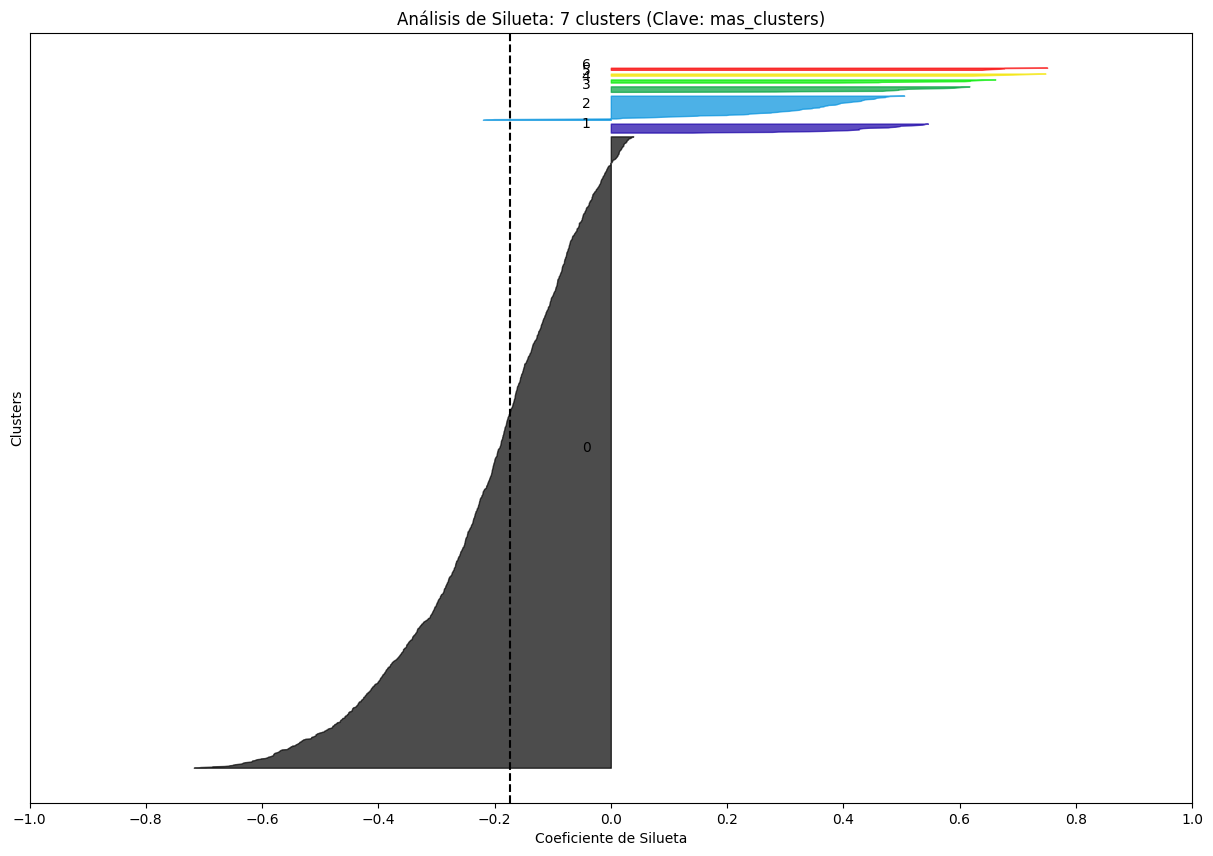

mas_clusters -> Score Promedio: -0.1741


In [28]:
# Formamos el dict con los valores
resultados_clusters = {'mas_clusters': resultados_dbscan[1][mask_8_22]}

# Mostramos el diagrama de sierra para mas clusters
dibujar_diagrama_sierra(dataset_spotify_preprocesado[mask_8_22], resultados_clusters)

Ahora para `min_samples=16 y eps=0.2524:`

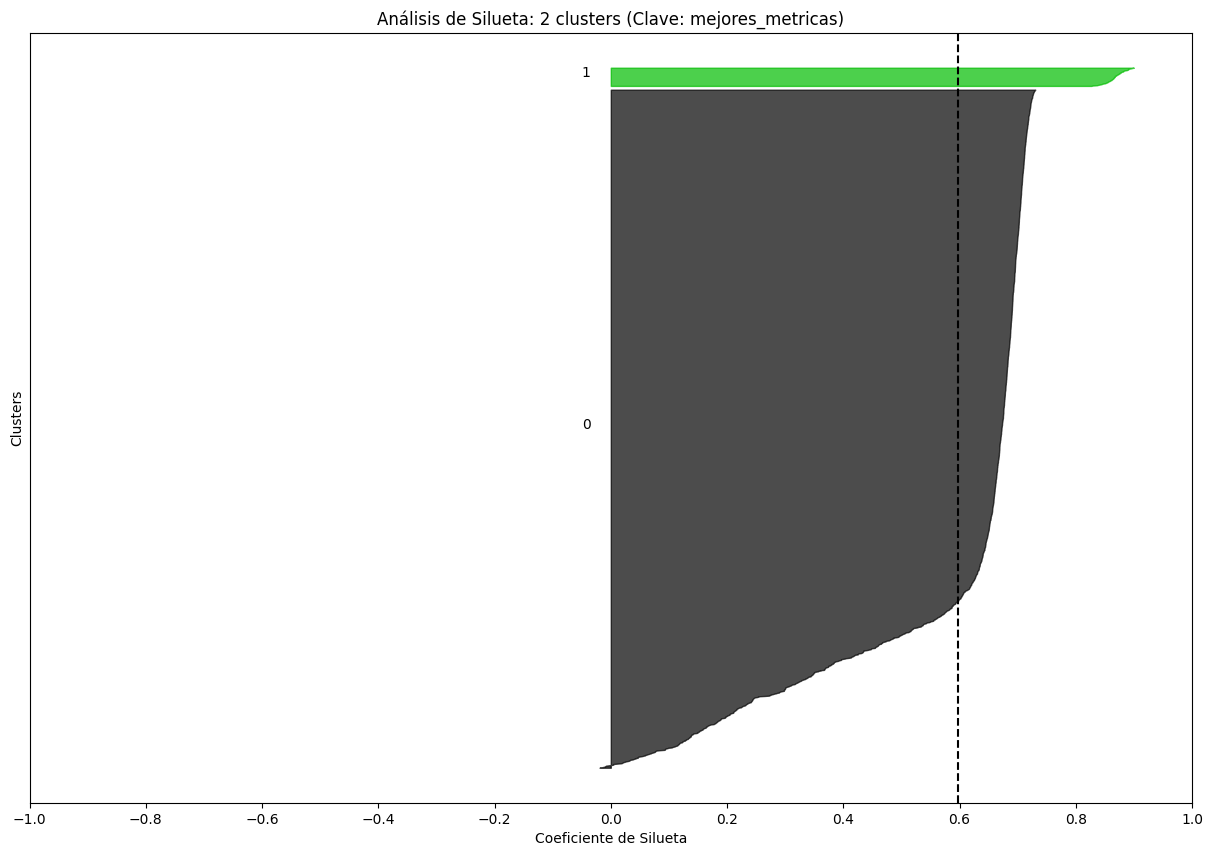

mejores_metricas -> Score Promedio: 0.5980


In [29]:
# Formamos el dict con los valores
resultados_clusters = {'mejores_metricas': resultados_dbscan[2][mask_16_25]}

# Mostramos el diagrama de sierra
dibujar_diagrama_sierra(dataset_spotify_preprocesado[mask_16_25], resultados_clusters)

##### **Observaciones**
Los diagramas de sierra solo confirman lo que vemos:
- Menos clústers, `mejor estructura, mejor score.`
- Más clústers, `sin estructura, peor score.`

Como silueta falla al ver formas que no son elipsoidales, explica el por qué de nuestro `mal score con muchos clústers.`

### **Tarea 3.5**
Nos piden: **`¿Cuál es el número óptimo de clusters? ¿por qué?`**

- Respuesta según scores: `el número óptimo es 2 clústers.`
- Respuesta según análisis más alla de las mates: `7 clústers es lo mejor, al tener más variedad y tener un score fiable (Davies) regular-bueno.`

En la tarea 3.4, indirectamente hemos respondido esto, solo estamos confirmando lo que opinamos, **¿O preferís solo 2 clústers bien agrupados?**

#### **¿Qué géneros son los clústers?**
Para terminar, vamos a analizar los 2 resultados y viendo los posibles `clústers (géneros musicales) que formamos.`

##### **Para los 7 clústers**
Sacamos el promedio de los clústers (y del ruido por curiosidad):

In [30]:
# Media de los clusters
df_comparar_8_22.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.394666,0.578372,0.479648,0.550839,0.218247,0.205573,0.097166,0.514698
0,0.274889,0.642074,0.489233,0.615082,0.002457,0.131550,0.052187,0.496969
1,0.991111,0.696111,0.305475,0.018401,0.959815,0.108489,0.074081,0.366718
2,0.937296,0.605986,0.439171,0.123832,0.914296,0.105823,0.041311,0.469368
3,0.983706,0.332176,0.440572,0.030595,0.930353,0.086912,0.044788,0.296942
4,0.966600,0.113450,0.461910,0.020091,0.892200,0.098080,0.041820,0.316684
5,0.312286,0.677000,0.462423,0.664714,0.000226,0.113743,0.055557,0.682132
6,0.147800,0.747857,0.491711,0.674286,0.000127,0.396714,0.037743,0.500394


Con estos datos, podemos inferir los géneros:

| Clúster | Género / Mood Probable | Justificación |
| :---: | :--- | :--- |
| **-1** | **Mezcla / Ruido / Outliers** | Valores intermedios en todo: energía media (0.55), danceability media (0.57), instrumentalness moderada (0.21). No forma un estilo claro → puntos que DBSCAN no asigna a ningún patrón. |
| **0** | **Pop / Dance Moderno** | Danceability alta (0.64), energía alta (0.61), instrumentalness casi nula. Estructura típica de música comercial y radiofórmula. |
| **1** | **Folk / Acústico Puro** | Acousticness casi máximo (0.99), energía mínima (0.01), instrumentalness altísima (0.95). Sonido muy orgánico, suave y sin percusión fuerte. |
| **2** | **Pop Acústico / Indie Suave** | Muy acústico (0.93) pero con más ritmo (danceability 0.60) que el clúster 1. Canciones de autor con base rítmica ligera. |
| **3** | **Ambient / New Age / Clásica Suave** | Instrumentalness altísima (0.93), energía muy baja (0.03), tempo lento. Música ambiental, relajante o clásica minimalista. |
| **4** | **Hip‑Hop / Rap Suave** | Speechiness relativamente alto (0.04–0.05), liveness moderado, energía muy baja. Mezcla de voz hablada con bases suaves. |
| **5** | **Pop‑Rock / Mainstream** | Energía alta (0.66), danceability alta (0.67), instrumentalness casi cero. Sonido de banda moderna con ritmo marcado. |
| **6** | **Rock Alternativo / Indie Rock** | Energía alta (0.67), danceability alta (0.74), liveness muy alto (0.39). Sonido de banda con presencia de directo y ritmo fuerte. |

Lo bueno, es que de los **6 géneros que tenemos de base,** logramos acertar `Con Pop (clúster 0), Folk (clúster 1), Rock (clúster 6) y Hip-Hop/Rap (clúster 4).` Parcialmente, lo hacemos con `Clásica (clúster 3) y Electronic (repartido entre el clúster 0 y 2).` Hemos cubierto **un nuevo género llamado `Ambient/New Age,` correspondiente con el `clúster 3` (justo el que tenía algo de música clásica, la cual esta muy relacionada con este nuevo género).** Podemos quedarnos satisfechos con la labor de DBSCAN.

##### **Para los 2 clústers**
Hacemos lo mismo:

In [31]:
# Media de los clusters
df_comparar_16_25.groupby('cluster').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,speechiness,tempo
cluster,,,,,,,,
-1,0.421001,0.572998,0.476745,0.532291,0.246579,0.205080,0.097204,0.510277
0,0.267020,0.643099,0.489270,0.618609,0.003431,0.134312,0.053518,0.498280
1,0.930778,0.608333,0.442991,0.129731,0.905500,0.104119,0.042500,0.519348


Con estos datos, podemos inferir los géneros:

| Clúster | Género / Mood Probable | Justificación |
| :---: | :--- | :--- |
| **-1** | **Mezcla / Ruido / Outliers** | Valores intermedios en todo: energía media (0.53), danceability media (0.57), instrumentalness moderada (0.24). No forma un estilo claro → puntos que DBSCAN no asigna a ningún patrón. |
| **0** | **Pop / Dance Moderno** | Danceability alta (0.64), energía alta (0.61), instrumentalness casi nula. Sonido comercial, orientado a radio y playlists mainstream. |
| **1** | **Folk / Acústico Puro** | Acousticness altísimo (0.93), instrumentalness muy alta (0.90), energía muy baja. Sonido orgánico, suave, centrado en guitarras y voz. |

Con esto, `solo acertamos con Pop (clúster 0) y con Folk (clúster 1).` No hemos encontrado más géneros de los que tenñiamos de base, y obviamente, **NO hemos descubierto nuevos géneros.** Curiosamente, Folk y Pop (según internet), son `géneros bien distintos/diferenciados.` Esta puede ser la pista de por qué DBSCAN solo sacaba 2 clústers.

##### **¿Con cuál nos quedamos?**
Personalmente, creemos que `7 clústers han sido lo más ideal, asi que nos quedamos con este (más variedad y no solo 2 clústers).`